<a href="https://colab.research.google.com/github/00015775/learning-lab/blob/learn%2Fpytorch/pytorch/notebooks/03_youtube_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# stopped at 14:30



* `torchvision` - base domain library for PyTorch computer vision

* `torchvision.datasets` - get datasets and data loading functions for computer vision

* `torchvision.models` - get **pre-trained** computer vision models

* `torchvision.transforms` - functions for manipulating vision data to be suitable for an model inputs.

* `torch.utils.data.Dataset` - Base dataset class for PyTorch

* `torch.utils.data.DataLoader` - Create Python iterable over a dataset

In [2]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision import models
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

import sys


print(torch.__version__)
print(sys.version)

2.9.0+cu126
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [3]:

train_data = torchvision.datasets.FashionMNIST(root="./data",
                                               train=True,
                                               download=True,
                                               transform=torchvision.transforms.ToTensor(),
                                               target_transform=None)

test_data = torchvision.datasets.FashionMNIST(root="./data",
                                              train=False,
                                              download=False,
                                              transform=ToTensor(),
                                              target_transform=None)



100%|██████████| 26.4M/26.4M [00:03<00:00, 8.65MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 224kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.7MB/s]


In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
train_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [7]:
dir(train_data)

['__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_exists',
 '_check_legacy_exist',
 '_format_transform_repr',
 '_load_data',
 '_load_legacy_data',
 '_repr_indent',
 'class_to_idx',
 'classes',
 'data',
 'download',
 'extra_repr',
 'mirrors',
 'processed_folder',
 'raw_folder',
 'resources',
 'root',
 'target_transform',
 'targets',
 'test_data',
 'test_file',
 'test_labels',
 'train',
 'train_data',
 'train_labels',
 'training_file',
 'transform',
 'transforms']

In [8]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [9]:
train_data.root

'./data'

In [10]:
train_data.transforms

StandardTransform
Transform: ToTensor()

## Visualizing vision data

torch.Size([1, 28, 28]) 9


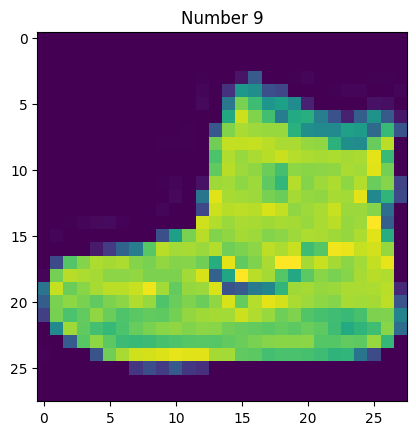

In [11]:
import matplotlib.pyplot as plt

image_0, label_0 = train_data[0]

print(image_0.shape, label_0) # label is scalar from 0-9

plt.imshow(image_0.permute(1,2,0)) # it expects [28, 28, 1]
plt.title("Number 9")
plt.show()

In [12]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

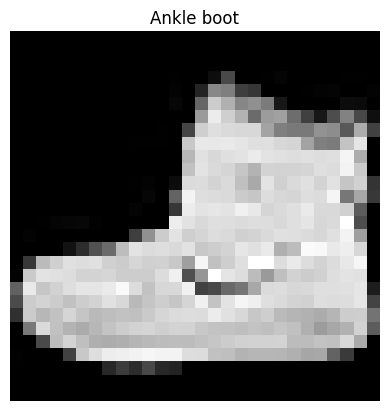

In [13]:
plt.imshow(image_0.squeeze(),
           cmap="gray")

plt.title(class_names[label_0])
plt.axis(False)

In [14]:
class_to_index = train_data.class_to_idx


index_to_class = dict((v, k) for k, v in class_to_index.items())

index_to_class

{0: 'T-shirt/top',
 1: 'Trouser',
 2: 'Pullover',
 3: 'Dress',
 4: 'Coat',
 5: 'Sandal',
 6: 'Shirt',
 7: 'Sneaker',
 8: 'Bag',
 9: 'Ankle boot'}

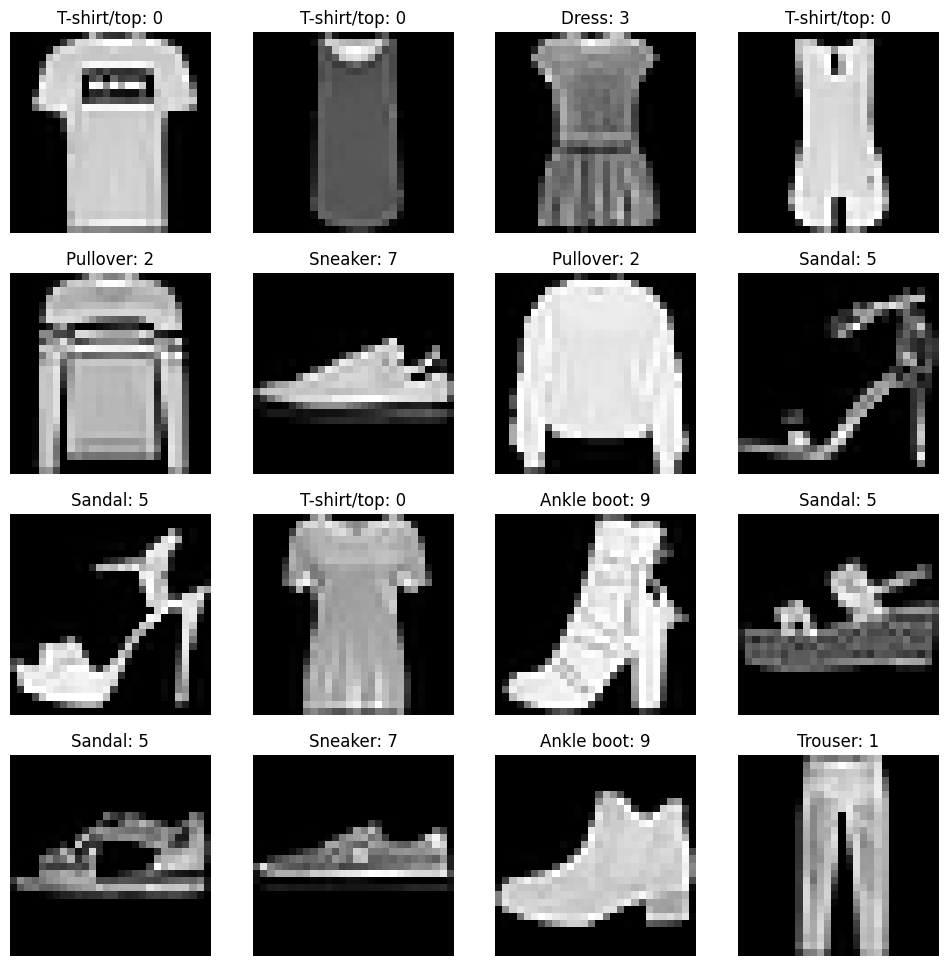

In [15]:
torch.manual_seed(55)

fig = plt.figure(figsize=(12,12))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  image_n, label_n = train_data[i]
  plt.subplot(rows, cols, i)
  plt.imshow(image_n.permute(1,2,0),
             cmap="gray")
  plt.title(f"{class_names[label_n]}: {label_n}")
  plt.axis(False)

In [16]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [17]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [18]:
from torch.utils.data import DataLoader, Dataset

BATCH_SIZE = 32

# python iterable iterface over dataset
train_loader = DataLoader(dataset=train_data,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

test_loader = DataLoader(dataset=test_data,
                         batch_size=BATCH_SIZE,
                         shuffle=False) # consistent comparison


In [19]:
len(train_data), len(test_data)

(60000, 10000)

In [20]:
60000/32, 10000/32

(1875.0, 312.5)

In [21]:
60000/BATCH_SIZE, 10000/BATCH_SIZE

(1875.0, 312.5)

In [22]:
# 1875 total batches for 60000 samples = BATCH_SIZE=32*1875=60.000
len(train_loader), len(test_loader)

(1875, 313)

In [23]:
train_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x7e7740ad2540>,
 <torch.utils.data.dataloader.DataLoader at 0x7e774197d310>)

In [24]:
train_features_batch, train_labels_batch = next(iter(train_loader))

# [BATCH=32, CHANNEL=1, HEIGHT=28, WEIGHT=28], the order may be different for other datasets
train_features_batch.shape, train_labels_batch.shape


(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

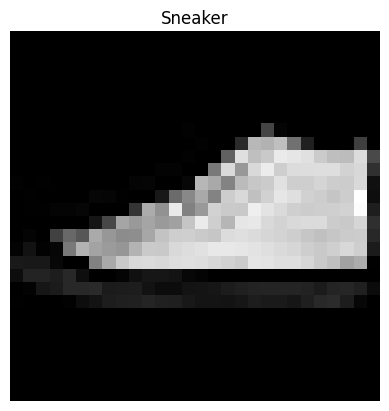

In [25]:
#torch.manual_seed(56)

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()

img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(img.squeeze(), cmap="grey")
plt.title(class_names[label])
plt.axis(False)

In [26]:
# stopped at 15:20

## Model 0:

When starting to build a series of machine learning modelling experiments, it's the best practice to start with a baseline model

A baseline model is a simple model you will try and improve upon with subsequent models/experiments.

In other words: start simply and add complexity when necessary one at a time, in order to understand which one contributes or degrades the accuracy

In [27]:
flatten_model = nn.Flatten()

flatten_model.eval()

with torch.inference_mode():
  x = train_features_batch[0]

  output = flatten_model(x)

print(x.shape)
print(output.shape)

# Flatten outputs tensor with only two dimensions, keeping the 0-indexed one
# While multiplying everything expect 0-indexed one

torch.Size([1, 28, 28])
torch.Size([1, 784])


In [28]:
A = torch.randn(12, 12, 3, 4, 5, 12)
out = flatten_model(A)
print(A.shape)
print(out.shape)

torch.Size([12, 12, 3, 4, 5, 12])
torch.Size([12, 8640])


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
from torch import nn

class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(

        # produces tensor of ndim=2, keeping 0-index one and multipliying the rest
        nn.Flatten(),

        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),

        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)


In [31]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(
    input_shape=784, # 28x28
    hidden_units=10,
    output_shape=len(class_names) # basically 10
    ).to(device)

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [32]:
dummy_x = torch.rand(1,1,28,28).to(device)

print(model_0(dummy_x), model_0(dummy_x).shape)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], device='cuda:0', grad_fn=<AddmmBackward0>) torch.Size([1, 10])


In [33]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]],
                     device='cuda:0')),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163], device='cuda:0')),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0

In [34]:
import requests
from pathlib import Path

# download .py from github repo
if Path("helper_functions.py").is_file():
  print(f"Already exists, skipping download...")
else:
  print("Downloading...")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)


Downloading...


In [35]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [36]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [37]:
import time

def print_train_time(start, end, device=None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format).
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    if total_time < 60:
      print(f"\nTrain time on {device}: {total_time:.3f} seconds")
    else:
      print(f"\nTrain time on {device}: {total_time/60:.3f} minutes")
    return total_time


In [38]:
from helper_functions import accuracy_fn, print_train_time

In [39]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(),
                            lr=0.01)


In [40]:
from tqdm.auto import tqdm
import time

torch.manual_seed(42)
torch.cuda.manual_seed(42)

start_time = time.time()

epochs = 3

model_0.to(device)

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----------")

  train_losses = 0
  # model_0.train()
  for batch, (X, y) in enumerate(train_loader):
    # write within the batch loop, because the below model_0.eval() will disable
    # certain training layers, and since we are inside of the loop
    # process will work as long as condition is true, hence it will be
    # on evaluation mode in the inner-loop
    # important/MUST to use before the forward pass of the training loop

    model_0.train()
    X = X.to(device)
    y = y.to(device)

    y_pred = model_0(X)
    loss = criterion(y_pred, y)
    train_losses += loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 400 == 0:
      print(f"Batch: {batch * len(X)}/{len(train_loader.dataset)} samples.")

  train_losses = train_losses / len(train_loader)

  test_losses, test_acc = 0, 0

  model_0.eval()
  with torch.inference_mode():
    for (X, y) in test_loader:
      X, y = X.to(device), y.to(device)
      test_pred = model_0(X)
      test_loss = criterion(test_pred, y)

      # cumulatitively adding loss
      test_losses += test_loss

      test_acc += accuracy_fn(y, test_pred.argmax(dim=1))

  test_losses = test_losses / len(test_loader)

  test_acc /= len(test_loader)

  print(f"\nTrain loss: {train_losses:.4f} | Test Loss: {test_losses:.4f}, Test Acc: {test_acc:.4f}")

end_time = time.time()
print_train_time(start=start_time,
                 end=end_time,
                 device=str(next(model_0.parameters()).device)
                 )


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----------
Batch: 0/60000 samples.
Batch: 12800/60000 samples.
Batch: 25600/60000 samples.
Batch: 38400/60000 samples.
Batch: 51200/60000 samples.

Train loss: 0.9096 | Test Loss: 0.6290, Test Acc: 78.6342
Epoch: 1
-----------
Batch: 0/60000 samples.
Batch: 12800/60000 samples.
Batch: 25600/60000 samples.
Batch: 38400/60000 samples.
Batch: 51200/60000 samples.

Train loss: 0.5573 | Test Loss: 0.5441, Test Acc: 81.1302
Epoch: 2
-----------
Batch: 0/60000 samples.
Batch: 12800/60000 samples.
Batch: 25600/60000 samples.
Batch: 38400/60000 samples.
Batch: 51200/60000 samples.

Train loss: 0.5027 | Test Loss: 0.5137, Test Acc: 81.9988

Train time on cuda:0: 42.621 seconds


42.62074613571167

In [41]:
# stopped at 16:00

In [42]:
train_losses

tensor(0.5027, device='cuda:0', grad_fn=<DivBackward0>)

In [43]:
len(train_loader.dataset)

60000

In [44]:
torch.manual_seed(42)

a = torch.rand(3,3)

print(a)
print(a.contiguous().view(-1)) # index=3 is the maximum value
print(torch.argmax(a)) # flattens the tensor and find the index of global max
print(torch.argmax(a, dim=0))
print(torch.argmax(a, dim=1))

tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])
tensor([0.8823, 0.9150, 0.3829, 0.9593, 0.3904, 0.6009, 0.2566, 0.7936, 0.9408])
tensor(3)
tensor([1, 0, 2])
tensor([1, 0, 2])


## Evaluation Function Loop (_avoids writing the same code again and again_)

In [59]:
from tqdm.auto import tqdm

torch.manual_seed(42) # for reproducibility

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """Returns a dictionary containing the results of model predicting on data_loader."""
  loss, acc = 0, 0
  model.eval()
  model.to(device)
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device)
      # forward pass
      y_pred = model(X)

      # cumulative loss and accuracy calculation
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y, y_pred.argmax(dim=1))

    # produces a scalar average loss and accuracy over total data points
    loss /= len(data_loader)
    acc /= len(data_loader)


  return {"model_name": model.__class__.__name__, # works if subclassed with nn.Module
          "model_loss": loss.item(),
          "model_acc": acc
          }

model_0_results = eval_model(model=model_0,
                             data_loader=test_loader,
                             loss_fn=criterion,
                             accuracy_fn=accuracy_fn)

model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5136751532554626,
 'model_acc': 81.9988019169329}

In [46]:
!nvidia-smi

Sat Jan 31 11:31:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P0             28W /   70W |     158MiB /  15360MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [47]:
next(model_0.parameters()).device

device(type='cuda', index=0)

## Model 1: Building a better model with non-linearity

In [48]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_shape: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(), # dim=1, produces ndim=2, keeping 0-index, and multiplying the rest
        nn.Linear(in_features=input_shape,
                  out_features=hidden_shape),
        nn.ReLU(),
        nn.Linear(in_features=hidden_shape,
                  out_features=output_shape),
        nn.ReLU()
    )

  def forward(self, x: torch.Tensor):
    return self.layer_stack(x)

In [49]:
len(class_names)

10

In [50]:
# when creating instance of the module class
# the random weights will be assigned, so manual_seed assures
# more or less the same random weights to be assigned in other machines as well
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_1 = FashionMNISTModelV1(
    input_shape=784, # flatten shape of 28 X 28 image
    hidden_shape=10,
    output_shape=len(class_names)
).to(device)

model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [51]:
next(model_1.parameters()).device

device(type='cuda', index=0)

In [52]:
# when flatten images either grey or RGB, the channel first approach is used
# because it preserves the image data along with its channels, be it grey or RGB
# [3, 28, 28] -> [3, 784] : look this preserves spatial information without being
# distorted or mixed with the channel dimensions

In [53]:
# optimization, helps to max/min acc/loss
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [54]:
# prediction with random weights
model_1_results = eval_model(model=model_1,
                             data_loader=test_loader,
                             loss_fn=criterion,
                             accuracy_fn=accuracy_fn)

model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 2.3021068572998047,
 'model_acc': 10.75279552715655}

## Training Function Loop (_avoids writing the same code again and again_)

* training loop = `train_step()`
* evaluation loop = `eval_model()`  
* testing loop = `test_step()`

In [55]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  """Performs a training with model trying to learn on a data_loader."""

  train_loss, train_acc = 0, 0

  model.to(device)

  for batch, (X, y) in enumerate(data_loader):
    model.train()
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss

    train_acc += accuracy_fn(y, y_pred.argmax(dim=1)) # logits -> prediction labels

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 400 == 0:
      print(f"Batch {batch * len(X)}/{len(train_loader)} samples")

  train_loss /= len(train_loader)
  train_acc /= len(train_loader)

  print(f"\nTrain loss: {train_loss:.4f} | Train acc: {train_acc:.2f}%")


In [56]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device=device):
  """Performs testing loop step on model going over data_loader."""

  test_loss, test_acc = 0, 0

  model.to(device)

  model.eval() # training layers are disables, less computations
  with torch.inference_mode(): # gradients are not calculated, less computations
    for batch, (X, y) in enumerate(data_loader):
      X, y = X.to(device), y.to(device)

      test_pred = model(X)

      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y, test_pred.argmax(dim=1)) # ensures shape compatibility

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.2f}%")


In [61]:
from tqdm.auto import tqdm # .auto helps to choose the best loading screen for given OS
import time

torch.manual_seed(56)
torch.cuda.manual_seed(56)

start_time = time.time()

epochs = 3

model_1.to(device)

for epoch in tqdm(range(epochs)):
  print(f"\nEpoch: {epoch}\n-----")

  train_step(model=model_1,
             data_loader=train_loader,
             loss_fn=criterion,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)

  test_step(model=model_1,
            data_loader=test_loader,
            loss_fn=criterion,
            accuracy_fn=accuracy_fn,
            device=device)

end_time = time.time()
print_train_time(start=start_time,
                 end=end_time,
                 device=str(next(model_1.parameters()).device)
                )


  0%|          | 0/3 [00:00<?, ?it/s]


Epoch: 0
-----
Batch 0/1875 samples
Batch 12800/1875 samples
Batch 25600/1875 samples
Batch 38400/1875 samples
Batch 51200/1875 samples

Train loss: 0.6402 | Train acc: 76.60%
Test loss: 0.6622 | Test acc: 76.10%

Epoch: 1
-----
Batch 0/1875 samples
Batch 12800/1875 samples
Batch 25600/1875 samples
Batch 38400/1875 samples
Batch 51200/1875 samples

Train loss: 0.6288 | Train acc: 76.99%
Test loss: 0.6506 | Test acc: 76.36%

Epoch: 2
-----
Batch 0/1875 samples
Batch 12800/1875 samples
Batch 25600/1875 samples
Batch 38400/1875 samples
Batch 51200/1875 samples

Train loss: 0.6191 | Train acc: 77.37%
Test loss: 0.6458 | Test acc: 76.80%

Train time on cuda:0: 29.452 seconds


29.452298164367676

In [62]:
# stopped at 17:09

In [63]:
model_1_results = eval_model(model=model_1,
                             data_loader=test_loader,
                             loss_fn=criterion,
                             accuracy_fn=accuracy_fn)

model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6458403468132019,
 'model_acc': 76.79712460063898}

### Total number of parameters

In [71]:
# Source - https://stackoverflow.com/a/49201237
# Posted by Fábio Perez, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-31, License - CC BY-SA 4.0

# trainable parameters
pytorch_total_train_params = sum(p.numel() for p in model_0.parameters() if p.requires_grad)
pytorch_total_train_params

7960

In [72]:
# Source - https://stackoverflow.com/a/49201237
# Posted by Fábio Perez, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-31, License - CC BY-SA 4.0

pytorch_total_params = sum(p.numel() for p in model_0.parameters())
pytorch_total_params

7960

In [70]:
# Source - https://stackoverflow.com/a/62508086
# Posted by Thong Nguyen, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-31, License - CC BY-SA 4.0

from prettytable import PrettyTable

def count_parameters(model):
    table = PrettyTable(["Modules", "Parameters"])
    total_params = 0
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        params = parameter.numel()
        table.add_row([name, params])
        total_params += params
    print(table)
    print(f"Total Trainable Params: {total_params}")
    return total_params

count_parameters(model_1)

+----------------------+------------+
|       Modules        | Parameters |
+----------------------+------------+
| layer_stack.1.weight |    7840    |
|  layer_stack.1.bias  |     10     |
| layer_stack.3.weight |    100     |
|  layer_stack.3.bias  |     10     |
+----------------------+------------+
Total Trainable Params: 7960


7960

In [74]:
for name, val in model_1.named_parameters():
  print(name, val.shape, val.numel())

layer_stack.1.weight torch.Size([10, 784]) 7840
layer_stack.1.bias torch.Size([10]) 10
layer_stack.3.weight torch.Size([10, 10]) 100
layer_stack.3.bias torch.Size([10]) 10


In [82]:
a = torch.rand(1,2,3,4,5,6)
print(a.numel()) # 1x2x3x4x5=120
# returns the total number of elements, by multiplying all dimensinos

b = torch.zeros(4,4)
print(torch.numel(b)) # 4x4=16

720
16


## CNN

Learn CNN explainer: https://poloclub.github.io/cnn-explainer/


In [229]:
from torch.nn.modules.pooling import MaxPool2d
class FashionMNISTModelV2(nn.Module):
  """
  Model architecture that replicates the ```TinyVGG```
  model from CNN explainer website
  """
  def __init__(self,  input_shape: int, hidden_shape: int, output_shape: int):
    super().__init__()
    # conv block composed of various layers
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_shape,
                  kernel_size=3,
                  stride=1,
                  padding=1), # stride=padding -> preserves spatial dimension
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_shape,
                  out_channels=hidden_shape,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    ) # -> torch.Size([16, 10, 14, 14])
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_shape,
                  out_channels=hidden_shape,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_shape,
                  out_channels=hidden_shape,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    ) # -> torch.Size([16, 10, 7, 7])
    self.classifier = nn.Sequential(
        nn.Flatten(start_dim=1, end_dim=-1), # -> torch.Size([16, 10*7*7]) -> [16, 490]
        nn.Linear(in_features=hidden_shape*7*7, # experiment to find out input shape
                  out_features=output_shape)
    )

  # print statements help to find out the output shape of each block, debugging
  def forward(self, x):
    x = self.conv_block_1(x)
    print(x.shape) # helps to determine the output shape
    x = self.conv_block_2(x)
    print(x.shape) # helps to determine the output shape
    x = self.classifier(x)
    print(x.shape)
    return x


In [221]:
torch.manual_seed(42)

model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_shape=10,
                              output_shape=len(class_names)).to(device)

model_2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### Trick to understand the output shape of conv block before feeding to classifier/fully-connected layer

In [222]:
torch.manual_seed(42)

images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0] # the first batch

print(images.shape)
print(test_image.shape)
print(test_image)

torch.Size([32, 3, 64, 64])
torch.Size([3, 64, 64])
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.7978,  1.0261,  1.1465,  ...,  1.2134,  0.9354, -0.

In [223]:
print(images.unsqueeze(dim=0).shape)

torch.Size([1, 32, 3, 64, 64])


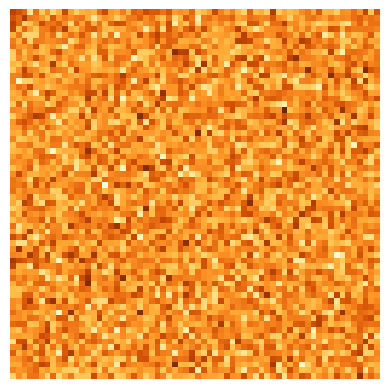

In [224]:
plt.imshow(images[0, 0], cmap="YlOrBr")
plt.axis(False)
plt.show()

In [225]:
# increases channel dimensions by learning new features
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=55,
                       kernel_size=(3,3),
                       stride=1,
                       padding=1)

outs = conv_layer(test_image)
print(test_image.shape)
print(outs.shape) # channels dimension created -> feature maps

torch.Size([3, 64, 64])
torch.Size([55, 64, 64])


In [226]:
# reduces the spatial dimensions
max_pool_layer = nn.MaxPool2d(kernel_size=3,
                              stride=1,
                              padding=0)

outs_pool = max_pool_layer(test_image)
print(test_image.shape)
print(outs_pool.shape)

torch.Size([3, 64, 64])
torch.Size([3, 62, 62])


In [227]:
torch.manual_seed(42)

max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2)
random_tensor = torch.rand(size=(1, 1, 2, 2))

max_pool_tensor = max_pool_layer(random_tensor)

print(random_tensor)
print(random_tensor.shape)
print(max_pool_tensor.shape)

tensor([[[[0.8823, 0.9150],
          [0.3829, 0.9593]]]])
torch.Size([1, 1, 2, 2])
torch.Size([1, 1, 1, 1])


In [231]:
model_2.eval()
with torch.inference_mode():
  logits = model_2(X)

# CONV_1 -> torch.Size([16, 10, 14, 14]) -> (N, C, H, W)
# CONV_2 -> torch.Size([16, 10, 7, 7]) -> (N, C, H, W)
# FC/Classifier -> torch.Size([16, 10]) -> BATCH_SIZE=16, NUM_CLASSES=10

torch.Size([16, 10, 14, 14])
torch.Size([16, 10, 7, 7])
torch.Size([16, 10])


In [232]:
# stopped at 18:12